# Loading and Exploring ODMR Data with QDMpy

This notebook demonstrates how to load and explore ODMR (Optically Detected Magnetic Resonance) data from a QDM (Quantum Diamond Microscope) measurement using QDMpy.

We use the `MIL2_FOV1` test dataset, which contains:
- Two MATLAB files (`run_00000.mat`, `run_00001.mat`) with ODMR spectra at two field polarities
- LED and laser reference images
- Acquisition metadata in header files

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from QDMpy.odmr.data import ODMRData
from QDMpy.odmr.io import MatlabLoader
from QDMpy.odmr.odmr import ODMR
from QDMpy.odmr.processors import BinningProcessor, NormalizationProcessor

2026-02-15 13:36:12.444 | INFO     | QDMpy:<module>:38 - WELCOME TO QDMpy
2026-02-15 13:36:12.445 | DEBUG    | QDMpy:<module>:39 - QDMpy version 0.1.0a installed at /home/mike/git/QDMpy/src/QDMpy
2026-02-15 13:36:12.445 | DEBUG    | QDMpy:<module>:40 - QDMpy config file /home/mike/.config/QDMpy/settings.toml


## 1. Load raw ODMR data

The `MatlabLoader` reads `run_*.mat` files from the data folder. Each file corresponds to
one field polarity and contains two image stacks (low-field and high-field frequency ranges)
with 51 frequency steps across a 1920 x 1200 pixel field of view.

In [2]:
DATA_FOLDER = Path.home() / 'git' / 'QDMpy' / 'tests' / 'data' / 'MIL2_FOV1'

loader = MatlabLoader(data_folder=str(DATA_FOLDER))
odmr_data = ODMRData.from_loader(loader)


Data shape: (2, 2, 1200, 1920, 51)
Dimensions: ('polarity', 'freq_range', 'y', 'x', 'freq_idx')
Scan dimensions (y, x): (1200, 1920)
Frequency ranges: 2
Frequencies per range: 51


## 2. Inspect the xarray DataArray

The data is stored as a 5D `xarray.DataArray` with named dimensions:
- `polarity` — field polarity (one per `.mat` file)
- `freq_range` — low-field vs high-field frequency band
- `y`, `x` — spatial pixel coordinates
- `freq_idx` — frequency sweep index

Actual frequency values in GHz are stored as a non-dimension coordinate `freq_ghz`.

In [3]:
odmr_data.data

<xarray.DataArray (polarity: 2, freq_range: 2, y: 1200, x: 1920, freq_idx: 51)> Size: 4GB
array([[[[[0.98293855, 0.98255049, 0.98237327, ..., 0.98234963,
           0.98190615, 0.98211046],
          [0.98270634, 0.9821743 , 0.98295283, ..., 0.98220875,
           0.98200447, 0.98248516],
          [0.98223778, 0.98189767, 0.9822132 , ..., 0.98224757,
           0.98234219, 0.98250858],
          ...,
          [0.98240601, 0.98156733, 0.98299475, ..., 0.98281256,
           0.98164887, 0.9822598 ],
          [0.98247129, 0.98305621, 0.98281471, ..., 0.98210023,
           0.98312218, 0.98267866],
          [0.98312303, 0.9836576 , 0.98375951, ..., 0.98210867,
           0.9822048 , 0.98134222]],

         [[0.98259217, 0.98273997, 0.98220567, ..., 0.98191149,
           0.98259238, 0.98193482],
          [0.98251943, 0.98227933, 0.98275746, ..., 0.98306639,
           0.98248483, 0.98169869],
          [0.9823511 , 0.98279712, 0.98267526, ..., 0.98187718,
           0.98172122, 0.98201717],
...
          [0.98365185, 0.98290684, 0.98329903, ..., 0.98404008,
           0.98384045, 0.98329959],
          [0.9836041 , 0.98295623, 0.98324533, ..., 0.98348643,
           0.98411886, 0.98288471],
          [0.98349064, 0.98387511, 0.98299548, ..., 0.98208091,
           0.98353712, 0.98422768]],

         [[0.98360551, 0.98362786, 0.98303198, ..., 0.98314939,
           0.98243026, 0.9838323 ],
          [0.98316162, 0.98255554, 0.98296702, ..., 0.98343   ,
           0.98354246, 0.98345199],
          [0.98269289, 0.98314271, 0.98319887, ..., 0.9834423 ,
           0.98376867, 0.98339341],
          ...,
          [0.98234501, 0.98372533, 0.98355091, ..., 0.98248481,
           0.98325733, 0.98345278],
          [0.98283755, 0.98265919, 0.98354431, ..., 0.98270771,
           0.98310156, 0.98252928],
          [0.98275814, 0.98259609, 0.98328594, ..., 0.98352295,
           0.98370178, 0.98396743]]]]])
Coordinates:
  * polarity    (polarity) <U5 40B 'pol_0' 'pol_1'
  * freq_range  (freq_range) <U8 64B 'frange_0' 'frange_1'
    freq_ghz    (freq_range, freq_idx) float64 816B 2.838 2.839 ... 2.902 2.902
Dimensions without coordinates: y, x, freq_idx

In [4]:
# Frequency values for each range (in GHz)
freq_ghz = odmr_data.data.coords['freq_ghz'].values
for _i in range(freq_ghz.shape[0]):
    pass

freq_range 0: 2.8383 - 2.8513 GHz
freq_range 1: 2.8894 - 2.9024 GHz


## 3. Load reference images

The dataset includes LED (white light) and laser images used for alignment and fluorescence correction.

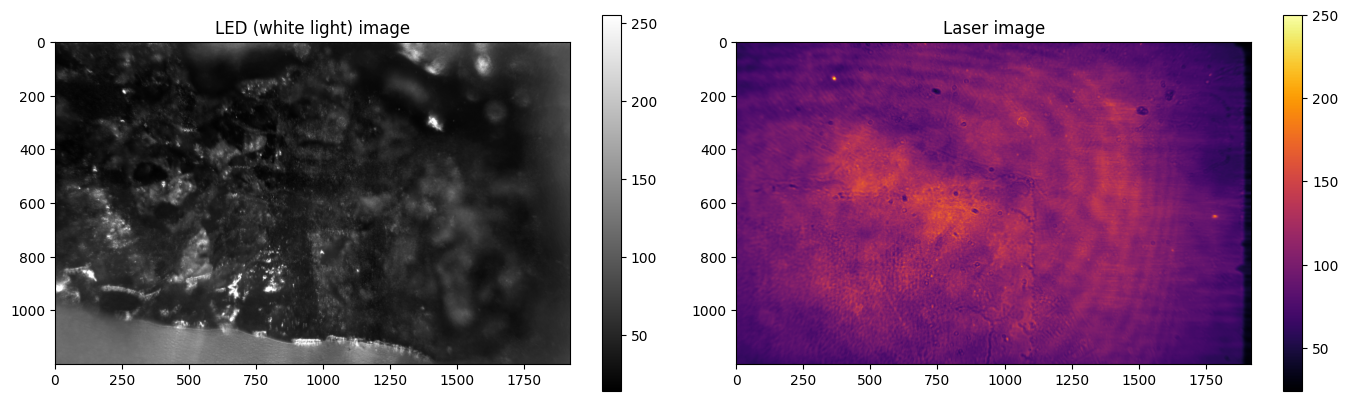

LED image shape: (1200, 1920)
Laser image shape: (1200, 1920)


In [10]:
led_image = np.loadtxt(DATA_FOLDER / 'LED.csv')
laser_image = np.loadtxt(DATA_FOLDER / 'laser.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(led_image, cmap='gray')
axes[0].set_title('LED (white light) image')
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(laser_image, cmap='inferno')
axes[1].set_title('Laser image')
fig.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()


## 4. Visualize mean ODMR spectra

Before any processing, let's look at the spatially-averaged ODMR spectra for each
polarity and frequency range. Each spectrum should show Lorentzian dips at the
NV center resonance frequencies.

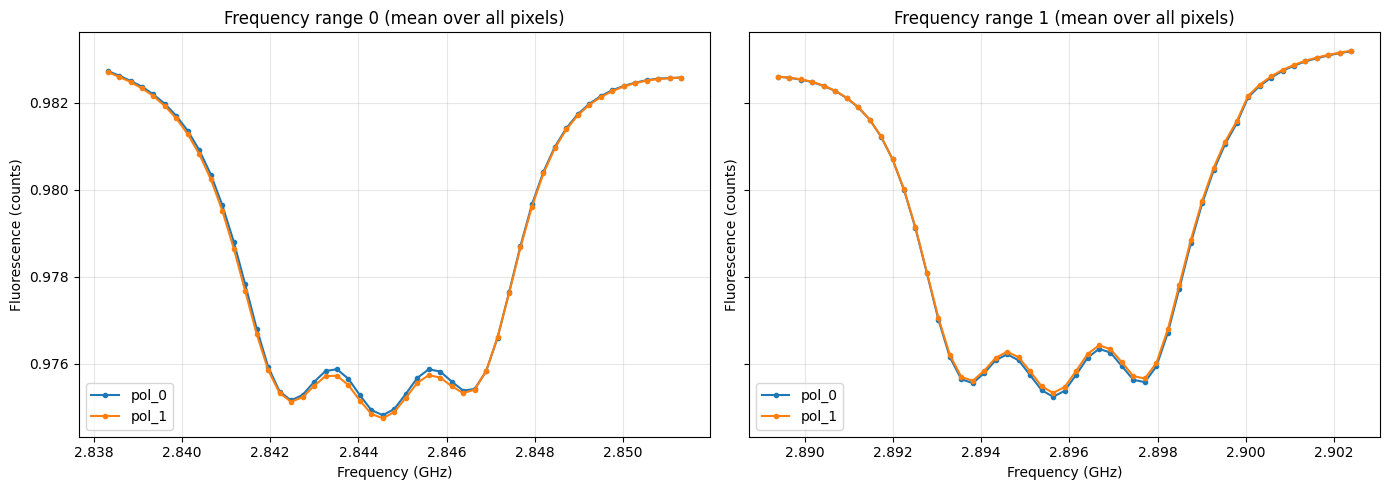

In [11]:
mean_spectra = odmr_data.data.mean(dim=['y', 'x'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
pol_labels = list(odmr_data.data.coords['polarity'].values)

for i_frange in range(odmr_data.data.sizes['freq_range']):
    ax = axes[i_frange]
    freqs = freq_ghz[i_frange]
    for i_pol in range(odmr_data.data.sizes['polarity']):
        spectrum = mean_spectra.isel(polarity=i_pol, freq_range=i_frange).values
        ax.plot(freqs, spectrum, 'o-', markersize=3, label=pol_labels[i_pol])
    ax.set_xlabel('Frequency (GHz)')
    ax.set_ylabel('Fluorescence (counts)')
    ax.set_title(f'Frequency range {i_frange} (mean over all pixels)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Apply processing pipeline

QDMpy uses a processor pipeline to prepare data for fitting:
1. **Spatial binning** — reduces noise by averaging adjacent pixels (e.g. 4x4)
2. **Normalization** — divides each spectrum by its maximum value so dip depths represent contrast

In [12]:
odmr = ODMR(odmr_data)

odmr.processor_manager.add_processor(BinningProcessor(bin_factor=4))
odmr.processor_manager.add_processor(NormalizationProcessor(method='max'))

odmr.process_data()


Raw data shape:       (2, 2, 1200, 1920, 51)
Processed data shape: (2, 2, 300, 480, 51)
Processors applied:   ['BinningProcessor', 'NormalizationProcessor']


## 6. Compare raw vs processed spectra

After binning and normalization, the spectra are smoother and the dips are easier
to identify. The y-axis now represents normalized contrast (1 = baseline).

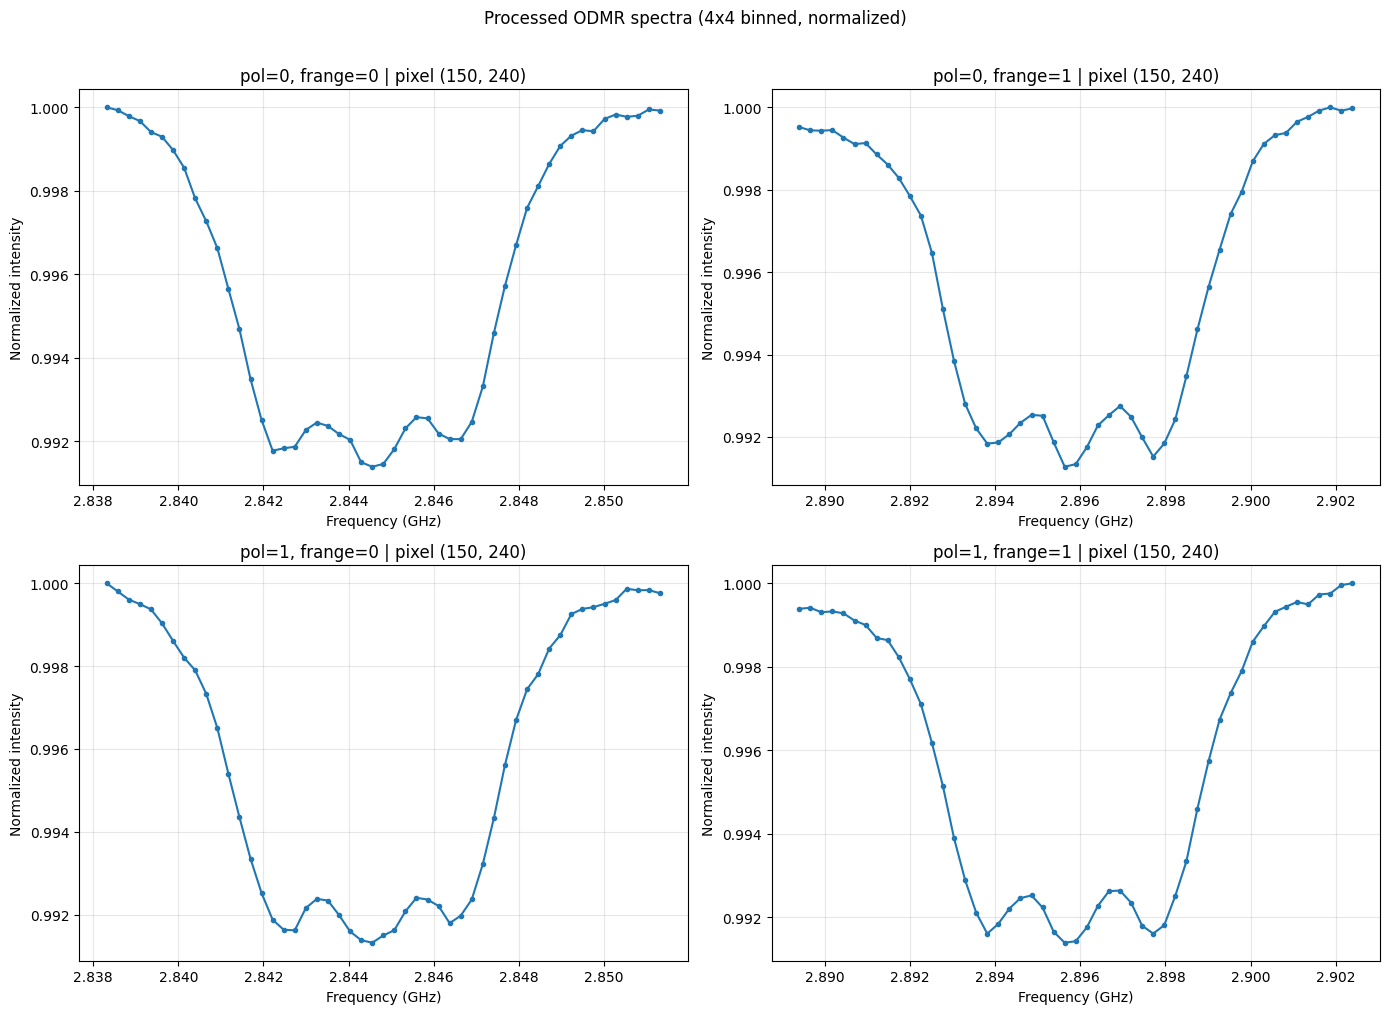

In [13]:
proc = odmr.processed_data

# Pick a pixel near the center of the binned image
cy, cx = proc.data.sizes['y'] // 2, proc.data.sizes['x'] // 2

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i_pol in range(proc.data.sizes['polarity']):
    for i_frange in range(proc.data.sizes['freq_range']):
        ax = axes[i_pol, i_frange]
        freqs = freq_ghz[i_frange]

        spectrum = proc.data.isel(
            polarity=i_pol, freq_range=i_frange, y=cy, x=cx
        ).values
        ax.plot(freqs, spectrum, 'o-', markersize=3, color='C0')

        ax.set_xlabel('Frequency (GHz)')
        ax.set_ylabel('Normalized intensity')
        ax.set_title(f'pol={i_pol}, frange={i_frange} | pixel ({cy}, {cx})')
        ax.grid(True, alpha=0.3)

plt.suptitle('Processed ODMR spectra (4x4 binned, normalized)', y=1.01)
plt.tight_layout()
plt.show()

## 7. Spatial maps of fluorescence and contrast

We can create spatial maps by reducing the frequency dimension. The mean
gives an overall fluorescence map, while the contrast (max - min along
frequency) highlights regions with strong ODMR signal.

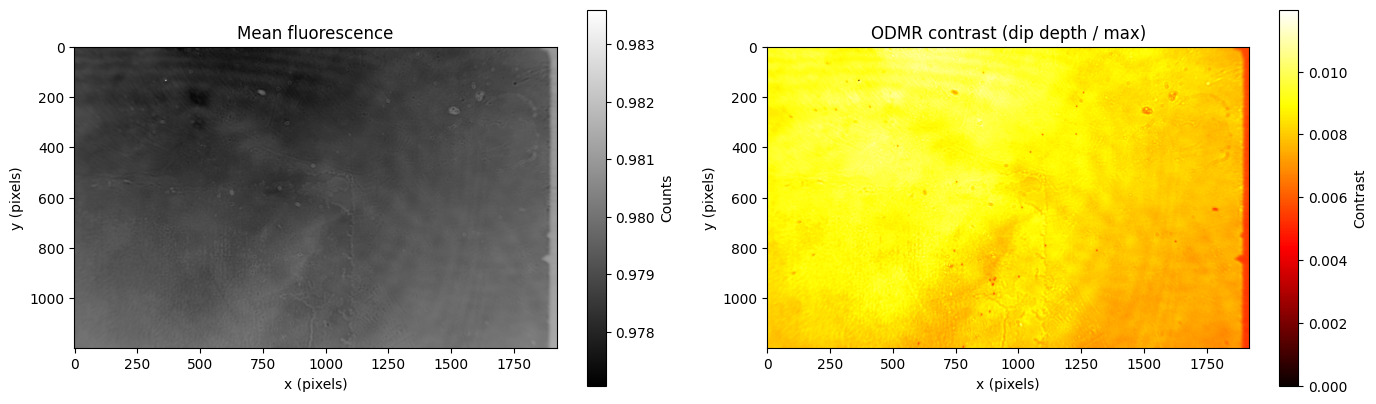

In [14]:
# Use raw (unbinned) data for full-resolution images
raw = odmr_data.data

# Fluorescence map: mean over frequency, averaged over polarities and ranges
fluorescence = raw.mean(dim=['polarity', 'freq_range', 'freq_idx'])

# Contrast map: (max - min) / max along frequency, averaged over pol/frange
spec_max = raw.max(dim='freq_idx')
spec_min = raw.min(dim='freq_idx')
contrast = ((spec_max - spec_min) / spec_max).mean(dim=['polarity', 'freq_range'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(fluorescence.values, cmap='gray')
axes[0].set_title('Mean fluorescence')
axes[0].set_xlabel('x (pixels)')
axes[0].set_ylabel('y (pixels)')
fig.colorbar(im0, ax=axes[0], shrink=0.8, label='Counts')

im1 = axes[1].imshow(contrast.values, cmap='hot')
axes[1].set_title('ODMR contrast (dip depth / max)')
axes[1].set_xlabel('x (pixels)')
axes[1].set_ylabel('y (pixels)')
fig.colorbar(im1, ax=axes[1], shrink=0.8, label='Contrast')

plt.tight_layout()
plt.show()

## 8. Interactive pixel exploration

Select a few pixels across the field of view and compare their spectra to
see how the ODMR response varies spatially.

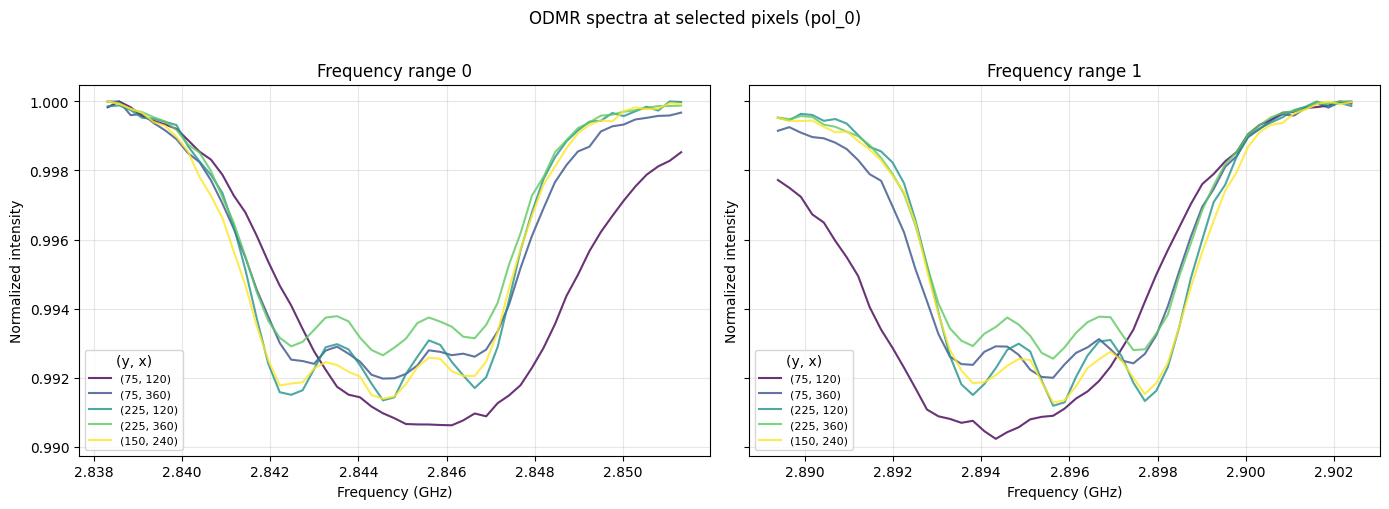

In [15]:
# Sample pixels at different locations in the binned data
ny, nx = proc.data.sizes['y'], proc.data.sizes['x']
sample_pixels = [
    (ny // 4, nx // 4),
    (ny // 4, 3 * nx // 4),
    (3 * ny // 4, nx // 4),
    (3 * ny // 4, 3 * nx // 4),
    (ny // 2, nx // 2),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(sample_pixels)))

for i_frange in range(proc.data.sizes['freq_range']):
    ax = axes[i_frange]
    freqs = freq_ghz[i_frange]
    for (py, px), color in zip(sample_pixels, colors):
        spectrum = proc.data.isel(
            polarity=0, freq_range=i_frange, y=py, x=px
        ).values
        ax.plot(freqs, spectrum, '-', color=color, alpha=0.8,
                label=f'({py}, {px})')
    ax.set_xlabel('Frequency (GHz)')
    ax.set_ylabel('Normalized intensity')
    ax.set_title(f'Frequency range {i_frange}')
    ax.legend(fontsize=8, title='(y, x)')
    ax.grid(True, alpha=0.3)

plt.suptitle('ODMR spectra at selected pixels (pol_0)', y=1.01)
plt.tight_layout()
plt.show()

## 9. Dip position map (quick estimate)

As a simple estimate of the resonance frequency at each pixel, we find the
frequency index of the minimum value. This gives a rough magnetic field map
without full fitting.

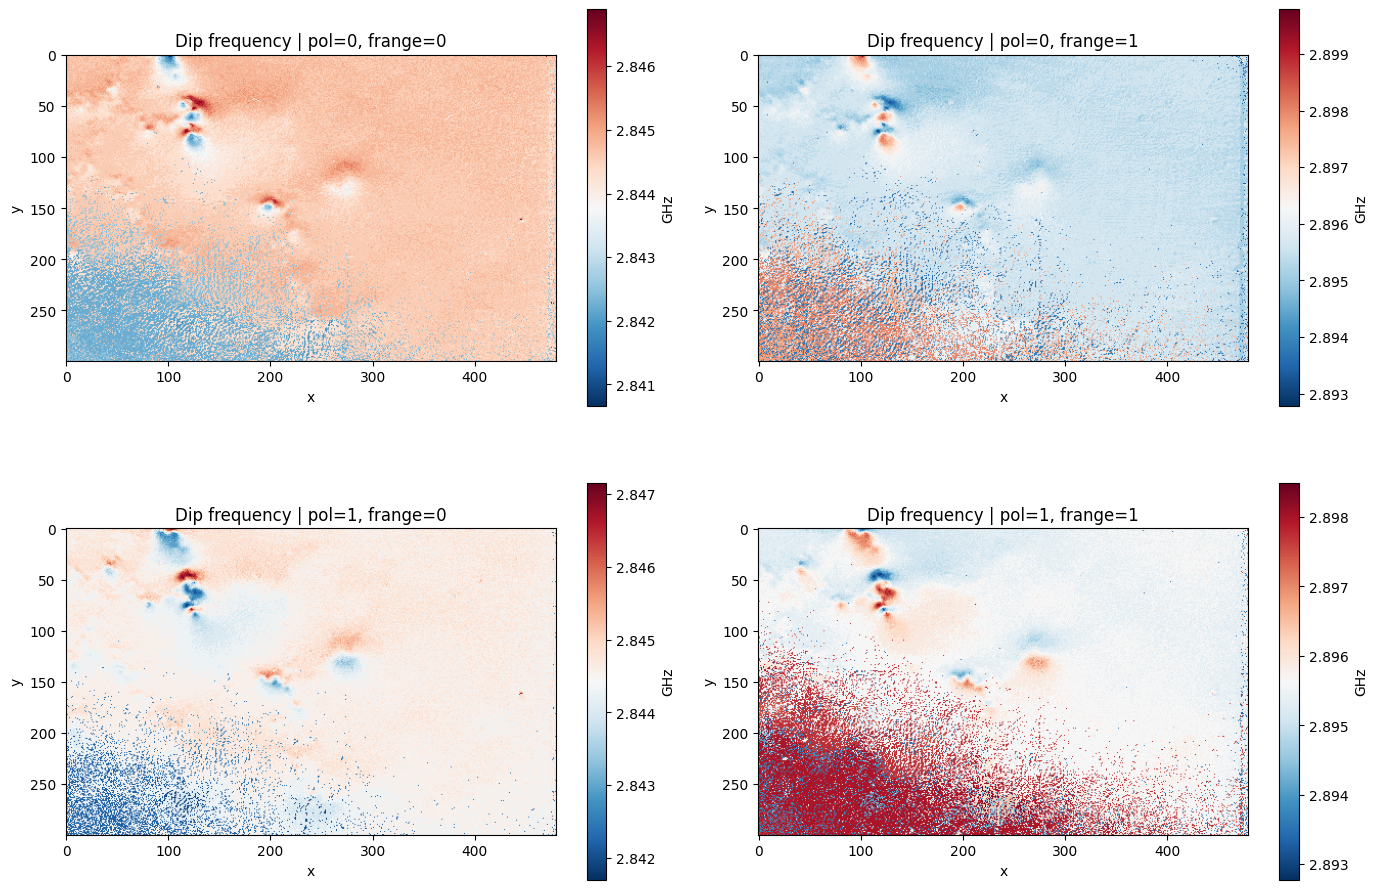

In [16]:
# Work with processed (binned + normalized) data
proc_da = proc.data

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i_pol in range(proc_da.sizes['polarity']):
    for i_frange in range(proc_da.sizes['freq_range']):
        ax = axes[i_pol, i_frange]
        freqs = freq_ghz[i_frange]

        # Index of minimum along frequency axis
        min_idx = proc_da.isel(
            polarity=i_pol, freq_range=i_frange
        ).argmin(dim='freq_idx').values

        # Map index to frequency in GHz
        dip_freq = freqs[min_idx]

        im = ax.imshow(dip_freq, cmap='RdBu_r')
        ax.set_title(f'Dip frequency | pol={i_pol}, frange={i_frange}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        fig.colorbar(im, ax=ax, shrink=0.8, label='GHz')

plt.tight_layout()
plt.show()

## 10. Data summary

In [17]:
for _i in range(freq_ghz.shape[0]):
    pass

Dataset summary
Data folder:         /home/mike/git/QDMpy/tests/data/MIL2_FOV1
Raw shape:           (2, 2, 1200, 1920, 51)
Processed shape:     (2, 2, 300, 480, 51)
Polarities:          2
Frequency ranges:    2
Spatial (raw):       1200 x 1920
Spatial (binned):    300 x 480
Frequencies/range:   51
  Range 0: 2.8383 - 2.8513 GHz
  Range 1: 2.8894 - 2.9024 GHz
LED image:           (1200, 1920)
Laser image:         (1200, 1920)
Processing pipeline: BinningProcessor -> NormalizationProcessor
